# Visualize Natural Forest Probabilities

This notebook loads the natural forest probability mosaic and renders it using a forest green palette.

In [1]:
from pathlib import Path

import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def find_repo_root(start: Path) -> Path | None:
    for candidate in [start] + list(start.parents):
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    return None

repo_root = find_repo_root(Path.cwd())
if repo_root is None:
    raise FileNotFoundError("Could not locate repo root containing data/ and notebooks/.")

mosaic_path = repo_root / "data/interim/bd_coastal_naturalforest_2020_mosaic.tif"

if not mosaic_path.exists():
    candidates = sorted((repo_root / "data/interim").glob("*naturalforest*.tif"))
    message = [
        f"Mosaic file not found at {mosaic_path}.",
        "Run scripts/forest/mosaic_naturalforest_tiles.py or update mosaic_path.",
    ]
    if candidates:
        message.append("Found these candidates under data/interim:\n  - " + "\n  - ".join(str(p) for p in candidates))
    raise FileNotFoundError("\n".join(message))

mosaic_path


PosixPath('/mnt/AAzizSSD/BDlulcModel/data/interim/bd_coastal_naturalforest_2020_mosaic.tif')

In [2]:
with rasterio.open(mosaic_path) as src:
    if src.count < 1:
        raise ValueError("No bands found in the mosaic file.")

    # Downsample for visualization to avoid huge memory use.
    max_dim = 2000
    scale = max(src.width / max_dim, src.height / max_dim, 1)
    out_width = int(src.width / scale)
    out_height = int(src.height / scale)

    band = src.read(
        1,
        out_shape=(out_height, out_width),
        resampling=rasterio.enums.Resampling.average,
    )

band.shape, band.min(), band.max()


((1618, 2000), np.uint8(0), np.uint8(245))

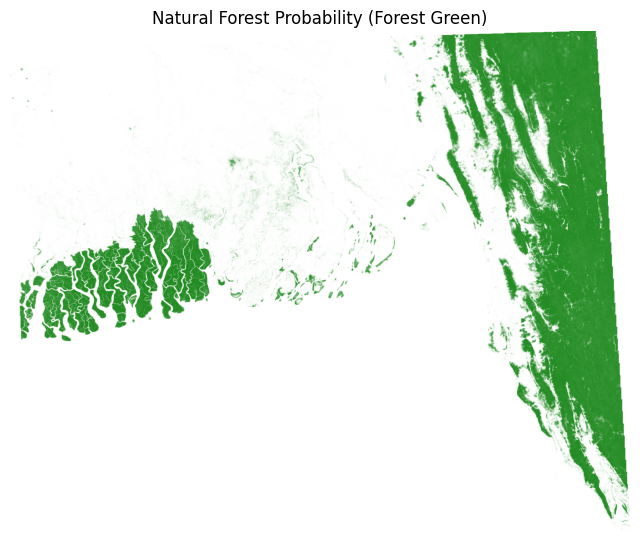

In [3]:
forest_cmap = LinearSegmentedColormap.from_list(
    "forestgreen", ["#ffffff", "forestgreen"]
)

plt.figure(figsize=(8, 8))
plt.imshow(band, cmap=forest_cmap)
plt.title("Natural Forest Probability (Forest Green)")
plt.axis("off")
plt.show()
